In [1]:
import os
os.chdir('../..')
print(os.getcwd())

/Users/titonka/FAIRIS


In [2]:
import pickle
import ipywidgets as widgets
from Simulation.libraries.SimulationLib.Environment import *
with open('logs/AllPPOTestDataFromTrain','rb') as file:
    experiment_data = pickle.load(file)
    

In [3]:
WM00_data = []
WM10_data = []
for d in experiment_data:
    if d.maze_file == 'WM00':
        WM00_data.append(d)
    else:
        WM10_data.append(d)

In [5]:
def plot_paths(maze, experiment):
    World = Maze('Simulation/worlds/mazes/Experiment1/'+maze+'.xml')
    i = experiment
    if maze == 'WM00':
        World.maze_figure_ax.plot(WM00_data[i].episodes[0].path_xs,WM00_data[i].episodes[0].path_ys)
        World.maze_figure_ax.plot(WM00_data[i].episodes[1].path_xs,WM00_data[i].episodes[1].path_ys)
        World.maze_figure_ax.plot(WM00_data[i].episodes[2].path_xs,WM00_data[i].episodes[2].path_ys)
        World.maze_figure_ax.plot(WM00_data[i].episodes[3].path_xs,WM00_data[i].episodes[3].path_ys)
    elif maze == 'WM10':
        World.maze_figure_ax.plot(WM10_data[i].episodes[0].path_xs,WM10_data[i].episodes[0].path_ys)
        World.maze_figure_ax.plot(WM10_data[i].episodes[1].path_xs,WM10_data[i].episodes[1].path_ys)
        World.maze_figure_ax.plot(WM10_data[i].episodes[2].path_xs,WM10_data[i].episodes[2].path_ys)
        World.maze_figure_ax.plot(WM10_data[i].episodes[3].path_xs,WM10_data[i].episodes[3].path_ys)
    return World.maze_figure
    

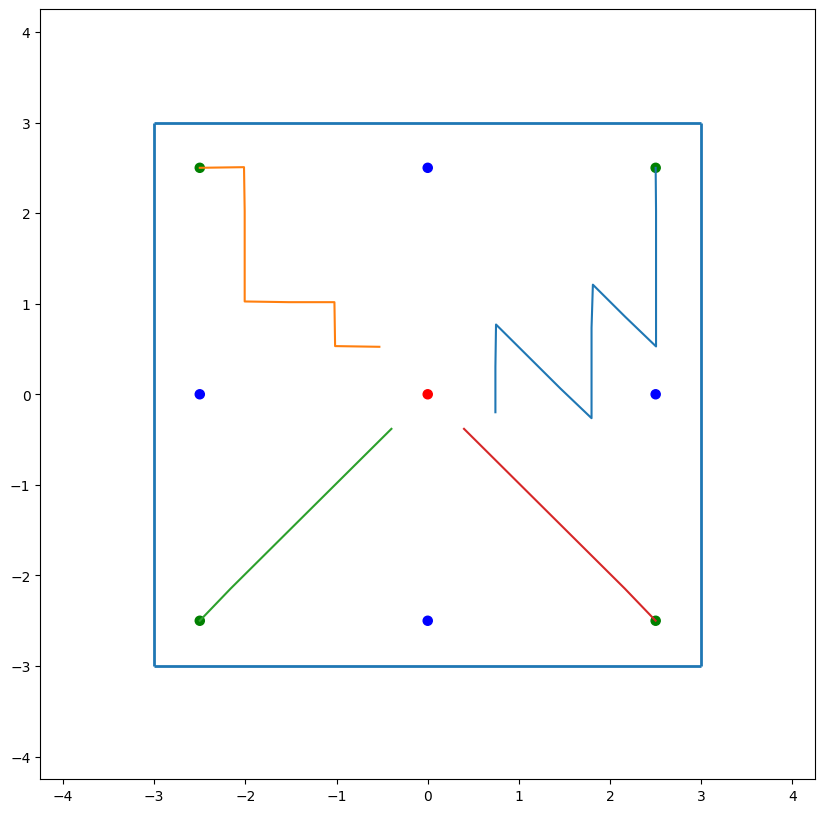

In [7]:
fig = plot_paths('WM00',14)

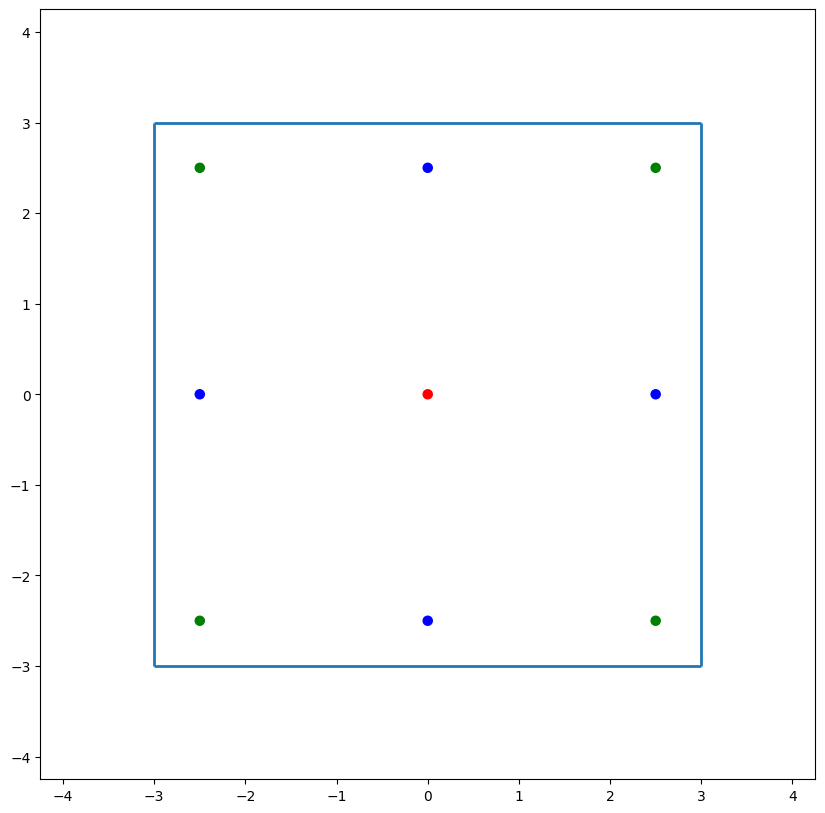

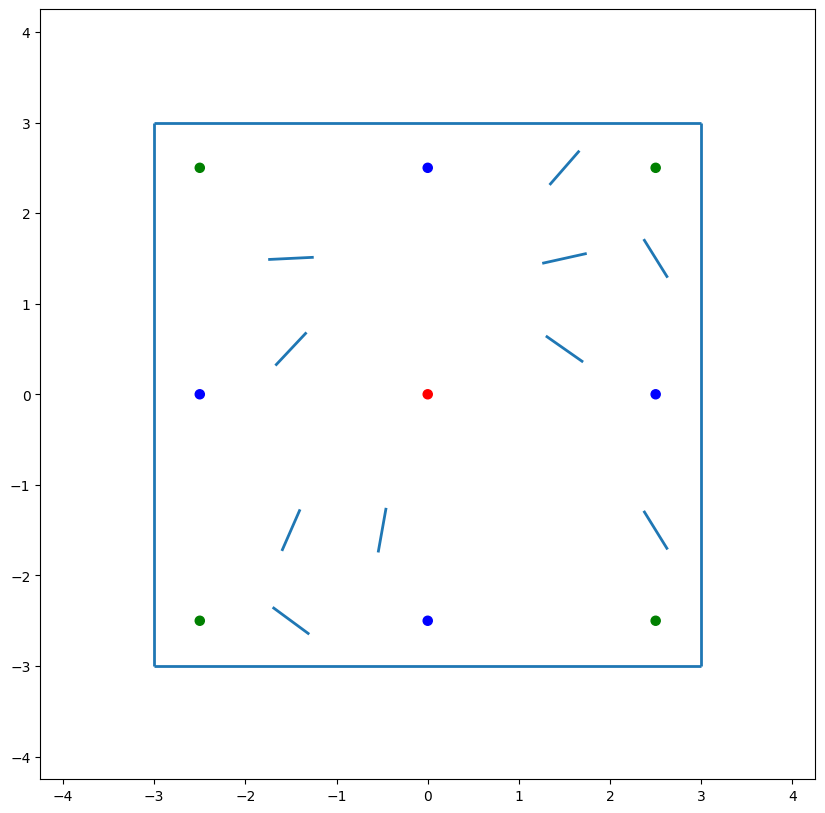

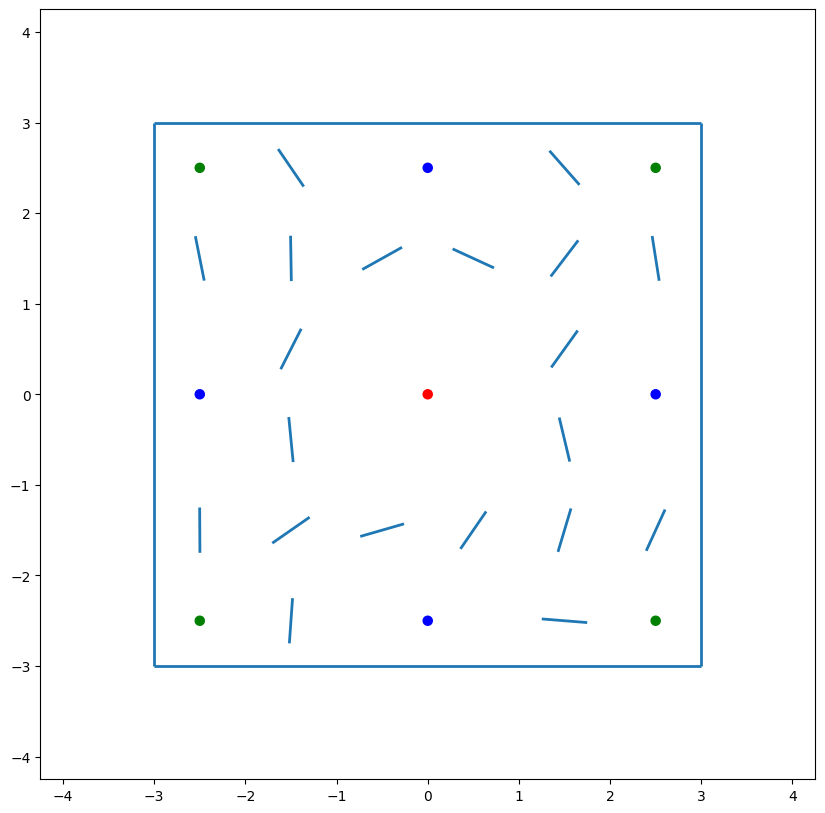

In [7]:
maze_files = ['WM00_paths.pkl','WM10_paths.pkl','WM20_paths.pkl']
mazes = []
for maze_file in maze_files:
    with open('Simulation/worlds/mazes/Experiment1/Paths/'+maze_file,'rb') as file:
        mazes.append(pickle.load(file))

In [8]:
class ShortestPath:
    def __init__(self,maze_file,starting_points,path_lengths):
        self.maze_file = maze_file
        self.starting_points = starting_points
        self.path_lengths = {
            starting_points[0] : path_lengths[0],
            starting_points[1] : path_lengths[1],
            starting_points[2] : path_lengths[2],
            starting_points[3] : path_lengths[3],
            starting_points[4] : path_lengths[4],
            starting_points[5] : path_lengths[5],
            starting_points[6] : path_lengths[6],
            starting_points[7] : path_lengths[7]
        }

In [9]:
maze_names = ['WM00','WM10','WM20']
path_data = []
name_index = 0
for maze in mazes:
    starting_points = []
    path_lengths = []
    for path in maze.paths:
        starting_points.append(path.path[0])
        path_lengths.append(len(path.path)-1)
    path_data.append(ShortestPath(maze_names[name_index],starting_points,path_lengths))
    name_index += 1

path_metrics = {
    'WM00': path_data[0],
    'WM10': path_data[1],
    'WM20': path_data[2]
}

In [10]:
pc_den_1 = [[],[]]
pc_den_2 = [[],[]]
pc_den_3 = [[],[]]
for experiment in experiment_data:
    pc_ver = experiment.pc_dist.split('_')[1]
    maze_ver = experiment.maze_file
    if maze_ver == 'WM00':
        data_index = 0
    elif maze_ver == 'WM10':
        data_index = 1
    shortest_path = path_metrics.get(maze_ver)
    for episode in experiment.episodes:
        start = (episode.path_xs[0] , episode.path_ys[0])
        min_dist = 100
        for s in shortest_path.starting_points:
            dist = math.sqrt((start[0] - s[0])**2 + (start[1]-s[1])**2)
            if dist < min_dist:
                min_dist = dist
                eps_start = s  
        min_length = int(shortest_path.path_lengths.get(eps_start))
        optimality_ratio = (episode.path_length - min_length)/min_length 
        if pc_ver == '0':
            pc_den_1[data_index].append(optimality_ratio)
        elif pc_ver == '1':
            pc_den_2[data_index].append(optimality_ratio)
        else:
            pc_den_3[data_index].append(optimality_ratio)

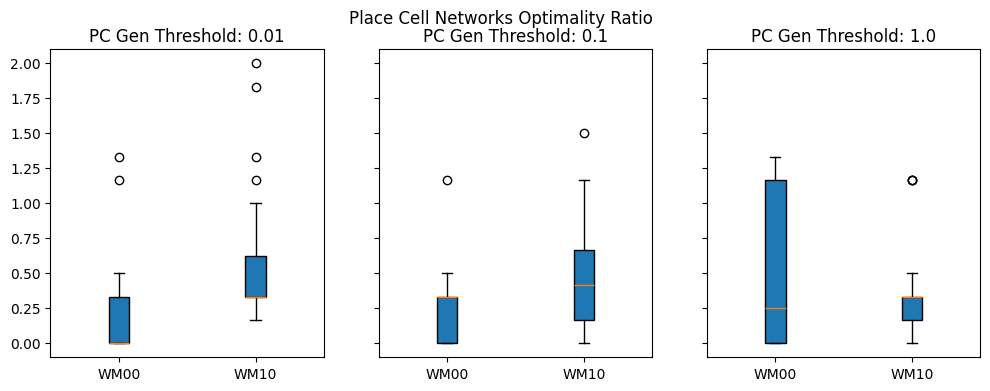

In [11]:
import matplotlib.pyplot as plt
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey = True, figsize = (12, 4))

ax1.boxplot([pc_den_1[0],pc_den_1[1]],patch_artist=True,
                notch=False)
ax1.set_xticklabels(['WM00', 'WM10'])
ax1.set_title('PC Gen Threshold: 0.01')

ax2.boxplot([pc_den_2[0],pc_den_2[1]],patch_artist=True,
                notch=False)
ax2.set_xticklabels(['WM00', 'WM10'])
ax2.set_title('PC Gen Threshold: 0.1')

ax3.boxplot([pc_den_3[0],pc_den_3[1]],patch_artist=True,
                notch=False)
ax3.set_xticklabels(['WM00', 'WM10'])
ax3.set_title('PC Gen Threshold: 1.0')

plt.suptitle('Place Cell Networks Optimality Ratio')

plt.show()